Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Load dataset

In [3]:
df = pd.read_csv("../data/raw/churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7044, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Data types

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7044 entries, 0 to 7043
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7044 non-null   str    
 1   gender            7044 non-null   str    
 2   SeniorCitizen     7044 non-null   int64  
 3   Partner           7044 non-null   str    
 4   Dependents        7044 non-null   str    
 5   tenure            7044 non-null   int64  
 6   PhoneService      7044 non-null   str    
 7   MultipleLines     7044 non-null   str    
 8   InternetService   7044 non-null   str    
 9   OnlineSecurity    7044 non-null   str    
 10  OnlineBackup      7044 non-null   str    
 11  DeviceProtection  7044 non-null   str    
 12  TechSupport       7044 non-null   str    
 13  StreamingTV       7044 non-null   str    
 14  StreamingMovies   7044 non-null   str    
 15  Contract          7044 non-null   str    
 16  PaperlessBilling  7044 non-null   str    
 17  Paymen

Missing values

In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Statistical summary

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7044,7044,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7044,2,Male,3556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7044.0,NaN,NaN,NaN,0.162124,0.36859,0.0,0.0,0.0,0.0,1.0
Partner,7044,2,No,3642,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7044,2,No,4934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7044.0,NaN,NaN,NaN,32.375923,24.561006,0.0,9.0,29.0,55.0,72.0
PhoneService,7044,2,Yes,6362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7044,3,No,3391,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7044,3,Fiber optic,3097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7044,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Target distribution

Churn
No     5175
Yes    1869
Name: count, dtype: int64


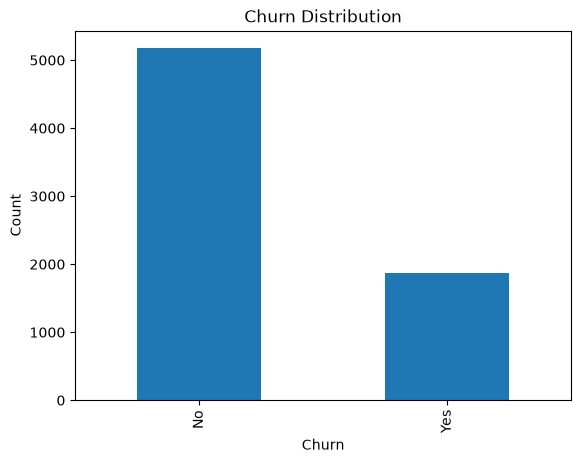

In [7]:
print(df["Churn"].value_counts())

df["Churn"].value_counts().plot(
    kind="bar",
    title="Churn Distribution"
)

plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

Categorical distributions

In [8]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for column in categorical_columns:
    if column != "customerID":
        print("\n", column)
        print(df[column].value_counts())


 gender
gender
Male      3556
Female    3488
Name: count, dtype: int64

 Partner
Partner
No     3642
Yes    3402
Name: count, dtype: int64

 Dependents
Dependents
No     4934
Yes    2110
Name: count, dtype: int64

 PhoneService
PhoneService
Yes    6362
No      682
Name: count, dtype: int64

 MultipleLines
MultipleLines
No                  3391
Yes                 2971
No phone service     682
Name: count, dtype: int64

 InternetService
InternetService
Fiber optic    3097
DSL            2421
No             1526
Name: count, dtype: int64

 OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2020
No internet service    1526
Name: count, dtype: int64

 OnlineBackup
OnlineBackup
No                     3089
Yes                    2429
No internet service    1526
Name: count, dtype: int64

 DeviceProtection
DeviceProtection
No                     3095
Yes                    2423
No internet service    1526
Name: count, dtype: int64

 TechSupport
TechSupport
No   

C:\Users\divin\AppData\Local\Temp\ipykernel_15984\2656009498.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(


Churn percentage

In [9]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percentage)

Churn
No     73.46678
Yes    26.53322
Name: proportion, dtype: float64


Numerical distributions

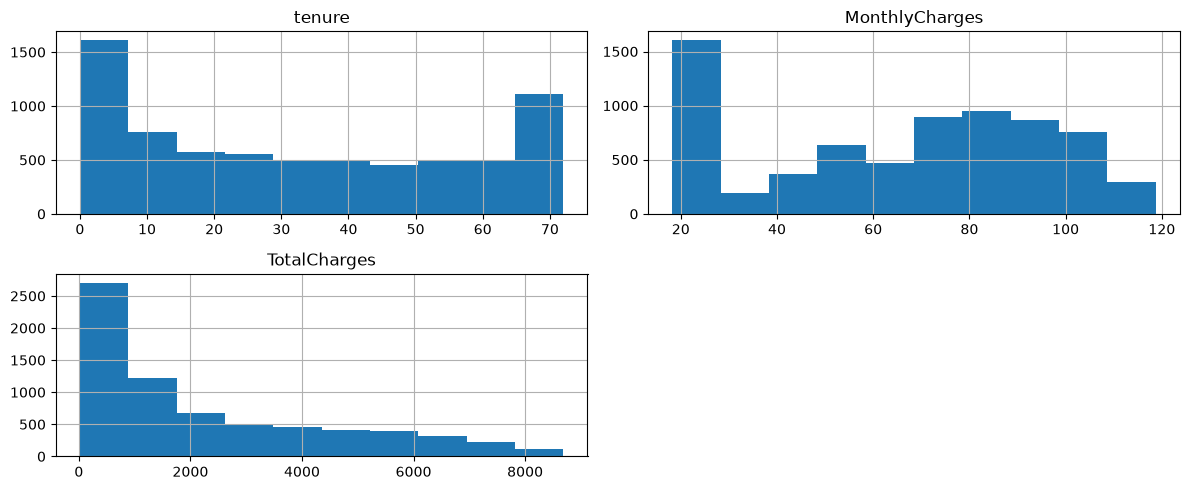

In [10]:
numerical_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for column in numerical_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df[numerical_columns].hist(
    figsize=(12, 5)
)

plt.tight_layout()
plt.show()

Churn vs Monthly Charges

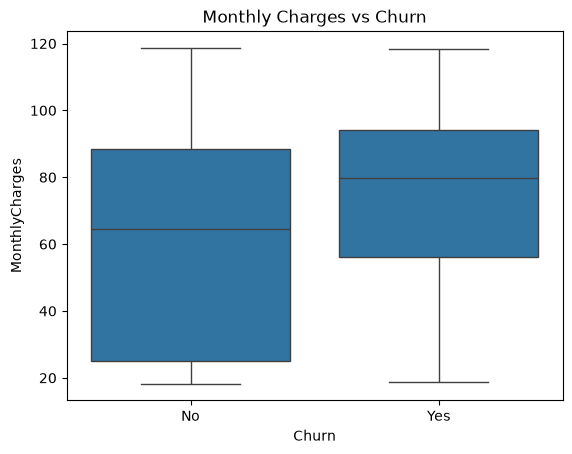

In [11]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

Churn vs Tenure

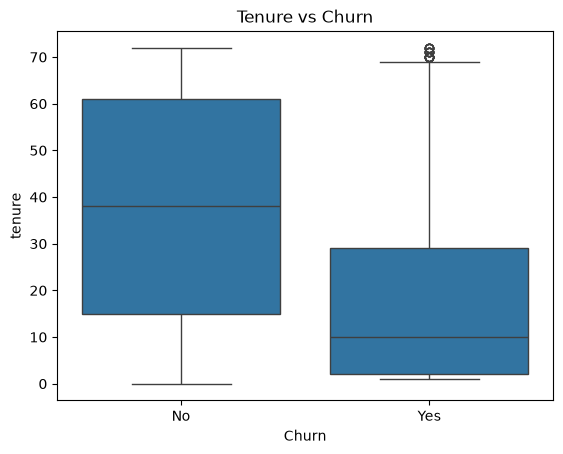

In [12]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

Correlation

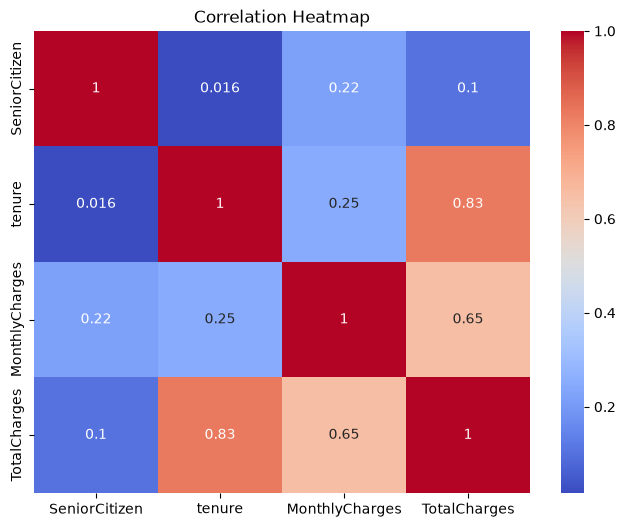

In [13]:
numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

Final observations

## EDA Observations

1. The dataset contains customer information related to telecommunications services.
2. The target variable is Churn.
3. Numerical and categorical features are present.
4. Missing values were inspected during EDA.
5. Customer churn distribution was visualized.
6. Numerical feature distributions were analyzed.
7. Relationships between churn and important numerical variables were visualized.
8. Correlation between numerical variables was examined.